### **Name : Vishesh Kumar**  
### **CU24250050**  
### **Sec: B**  
### **Roll No : 69**  
### **Computer Vision**  
### **Labsheet - 7**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cap = cv2.VideoCapture("video.mp4")

if not cap.isOpened():
    print("Error: Video not found")
else:
    print("Video loaded successfully")

Video loaded successfully


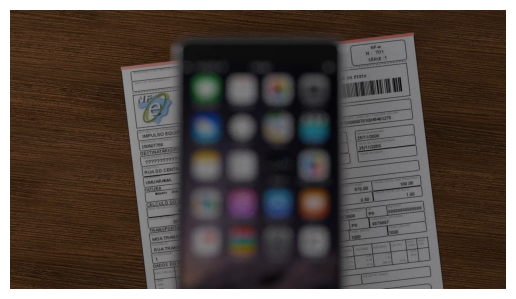

In [3]:
ret, old_frame = cap.read()

if not ret:
    print("Unable to read video")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(old_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [4]:
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

print("Feature points detected:", len(p0))

Feature points detected: 100


In [5]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

ret, frame = cap.read()
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

p1, status, error = cv2.calcOpticalFlowPyrLK(
    old_gray, frame_gray, p0, None, **lk_params
)

good_new = p1[status == 1]
good_old = p0[status == 1]

print("Tracked points:", len(good_new))

Tracked points: 100


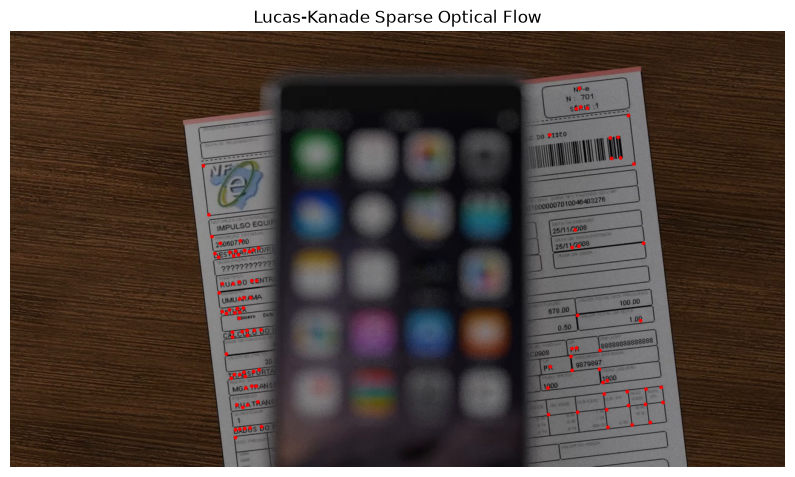

In [6]:
result = frame.copy()

for new, old in zip(good_new, good_old):
    x1, y1 = new.ravel()
    x2, y2 = old.ravel()

    cv2.arrowedLine(
        result,
        (int(x2), int(y2)),
        (int(x1), int(y1)),
        (0, 255, 0),
        2
    )
    cv2.circle(result, (int(x1), int(y1)), 3, (0, 0, 255), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.show()

In [7]:
flow = cv2.calcOpticalFlowFarneback(
    old_gray,
    frame_gray,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

print("Farneback Dense Optical Flow calculated")

Farneback Dense Optical Flow calculated


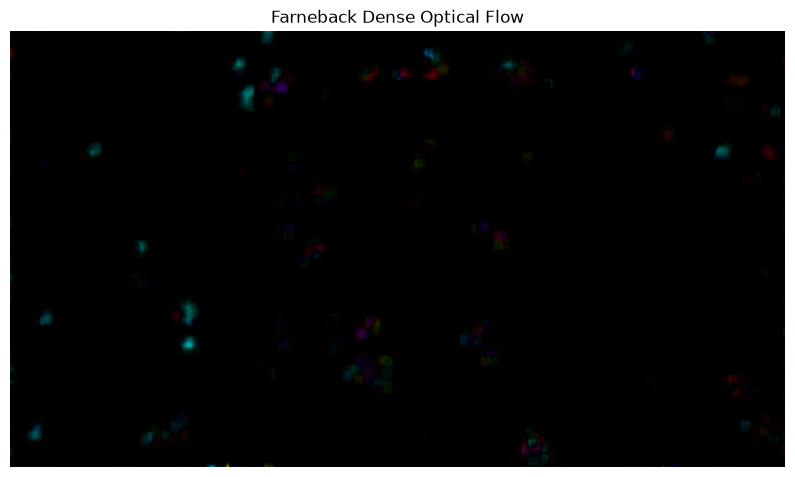

In [8]:
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

hsv = np.zeros_like(frame)
hsv[..., 1] = 255

hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

dense_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(dense_flow)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

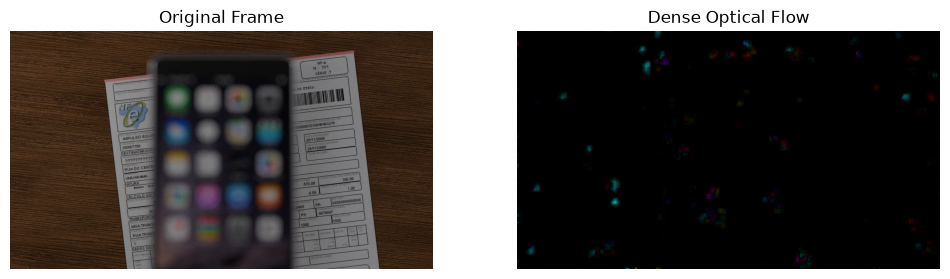

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dense_flow)
plt.title("Dense Optical Flow")
plt.axis("off")

plt.show()

In [10]:
print("Optical Flow Comparison")
print("-----------------------")
print("Lucas-Kanade : Sparse, tracks selected feature points")
print("Farneback    : Dense, estimates motion for almost every pixel")
print("Lucas-Kanade : Faster and suitable for object tracking")
print("Farneback    : More detailed but computationally expensive")

Optical Flow Comparison
-----------------------
Lucas-Kanade : Sparse, tracks selected feature points
Farneback    : Dense, estimates motion for almost every pixel
Lucas-Kanade : Faster and suitable for object tracking
Farneback    : More detailed but computationally expensive


In [11]:
cap.release()
print("Video processing completed successfully.");

Video processing completed successfully.
